In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v3 import NetLineStepProcessor
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import EMNIST
#from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
#from torchvision.utils import make_grid

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_eminst_epoch1d_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
                #datefmt="%Y-%m-%d %H:%M:%S,%(msecs)")
                #datefmt="%d/%m/%Y %I:%M:%S")


#### EMNIST dataset

In [3]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)
#train_dataset = MNIST(root=DATASET_PATH, train=True, download=True, transform=image_transform)
#test_dataset = MNIST(root=DATASET_PATH, train=False, download=True, transform=image_transform)

In [4]:
BATCH_SIZE = 128 #256 128 #96 #192 #96 #96 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

#### Metadata:

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM = 28 * 28
OUTPUT_DIM = 26 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 1000, 400 #2000, 800 #1024, 128 #1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 0.005, 5.0  #1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

NUM_EPOCH = 1 #00

##### UTILS

In [6]:
def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    
    plt.show()


#### Experiment 1

In [7]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

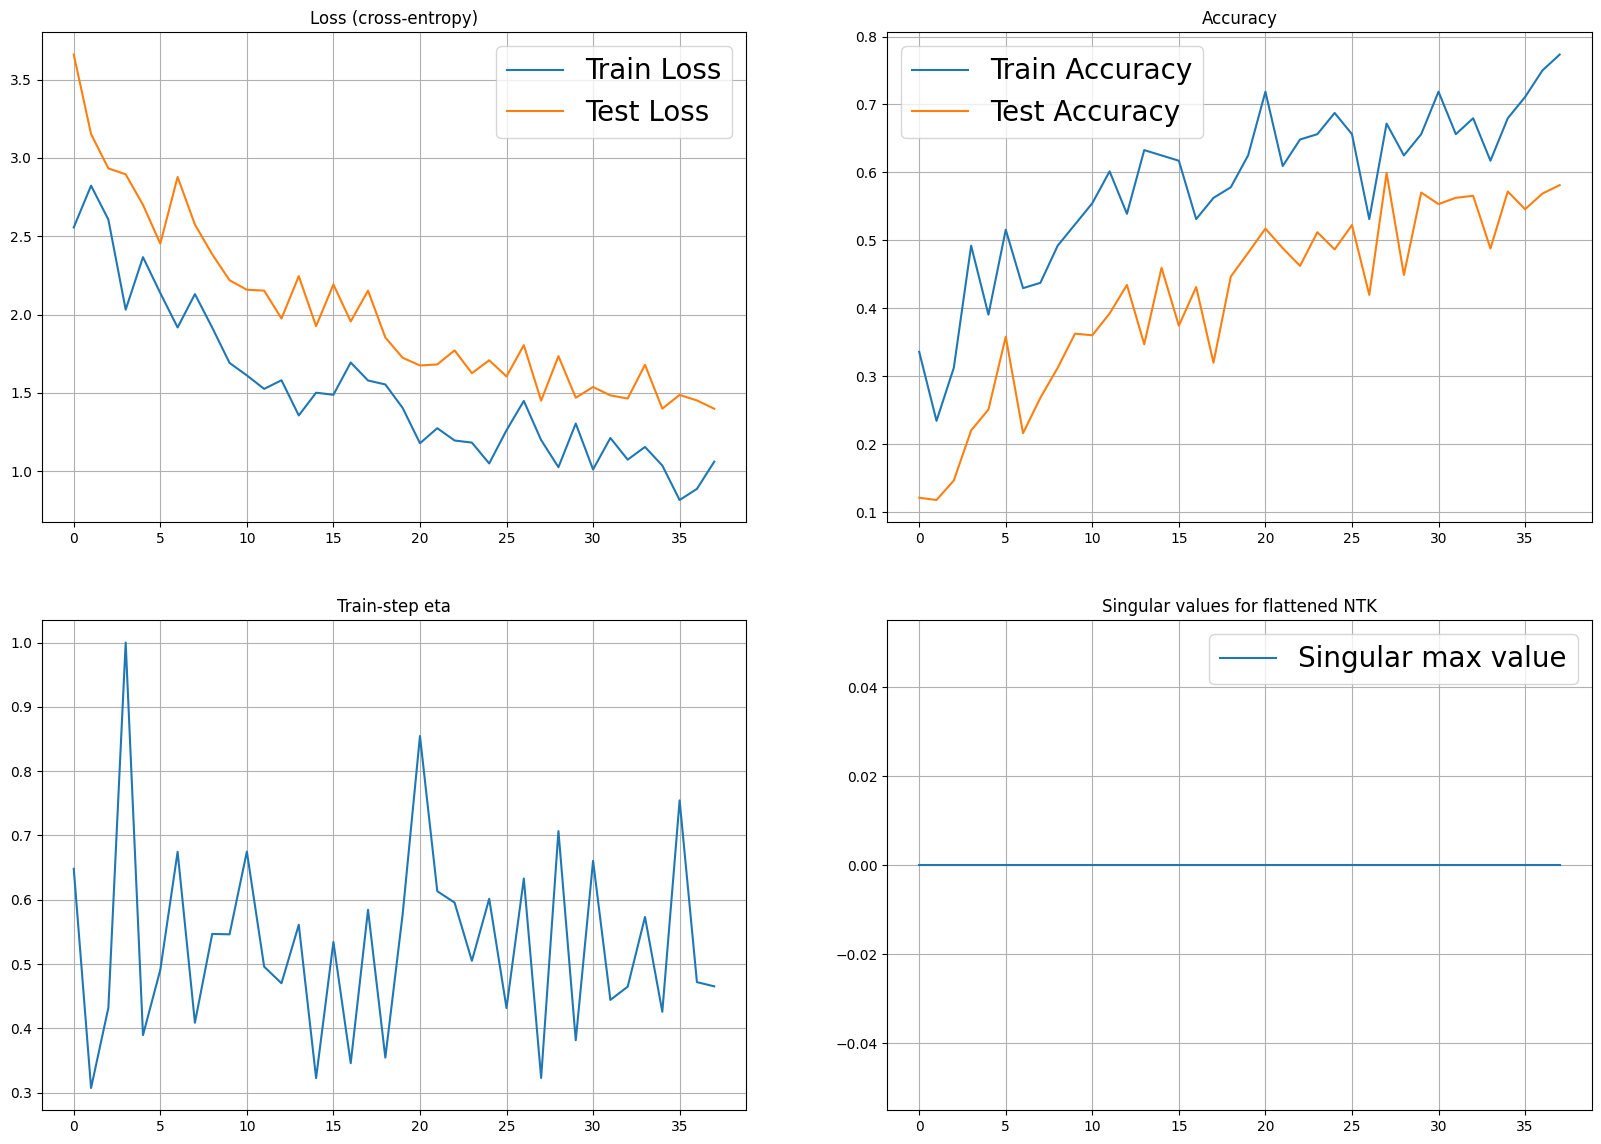

On epoch = 0 test accuracy = 0.581336273006135


In [ ]:
#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)
stepProcessor = NetLineStepProcessor(testNet, nn.CrossEntropyLoss(), meta, DEVICE) #reduction='sum'
stepProcessor.c1 = 0.0001
stepProcessor.eta0 = 0.000001
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = labels_raw -1 #torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().cpu().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        logging.info("##Step with NetLine norm2 optim")
        step_result = stepProcessor.step(labels, xx, momentum=0.0, nesterov=False)
        #labels, images, momentum, nesterov
        logits_latest = step_result.logits.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.cpu().numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['train_loss'].append(loss)
        HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_N2LAMBDA['train_eta'].append(step_result.eta)
        HISTORY_PARAMS_N2LAMBDA['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = labels_raw -1 #torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().cpu().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_N2LAMBDA)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))
        #break



In [9]:
#xx = torch.transpose(step_result.logits.detach(), 0, 1)
#xx.shape
#qq1 = (F.softmax(torch.transpose(logits, 0, 1), dim=0) + 1e-9)
sum(qq1[:,55])

NameError: name 'qq1' is not defined